# EXHEART 10 — Bootstrap confidence intervals on headline metrics

**Reviewer question this closes:** every headline number (AUC, sensitivity, ECE) and the new 0.022 drift estimate is a single point on a single split. A reviewer will ask whether they survive resampling.

**This notebook** computes test-set bootstrap CIs (B = 1000, matching the paper's existing fairness-CI methodology) on the BRFSS 2015 headline metrics and the Sex TPR gap, and, crucially, on the shared-feature transport **drift** estimate, so the paper can report "drift = 0.022, 95% CI [.,.]" instead of a bare point. Uses the committed stack; retrains the 11-feature transport model once for the drift CI. Outputs to `results/brfss2015/bootstrap_ci/` and `results/brfss2020/shared_feature_transport/`.

### 1. Determinism

In [1]:
import os
os.environ['PYTHONHASHSEED']='42'; os.environ['TF_DETERMINISTIC_OPS']='1'; os.environ['TF_CUDNN_DETERMINISTIC']='1'
import random, numpy as np, tensorflow as tf
SEED=42; random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
try: tf.config.experimental.enable_op_determinism()
except Exception as e: print(e)

### 2. Mount, git identity, paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import sys, json, shutil, joblib, warnings
import pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
DRIVE_ROOT='/content/drive/MyDrive/EXHEART_Research'; REPO_DIR=os.path.join(DRIVE_ROOT,'exheart-research')
for fn in ['.git-credentials','.gitconfig']:
    s=os.path.join(DRIVE_ROOT,fn)
    if os.path.exists(s): shutil.copy(s, os.path.join('/root',fn)); print('restored',fn)
DATA_2015=os.path.join(REPO_DIR,'data/brfss2015/heart_disease_health_indicators_BRFSS2015.csv')
DATA_2020=os.path.join(REPO_DIR,'data/brfss2020/heart_2020_cleaned.csv')
MODELS=os.path.join(REPO_DIR,'models/brfss2015')
RES_CI=os.path.join(REPO_DIR,'results/brfss2015/bootstrap_ci')
RES_TR=os.path.join(REPO_DIR,'results/brfss2020/shared_feature_transport')
for d in [RES_CI+'/tables',RES_CI+'/figures',RES_TR+'/tables']: os.makedirs(d,exist_ok=True)
print('Paths ready.')

Mounted at /content/drive
Paths ready.


### 3. Libraries + metric helpers

In [3]:
!pip install -q scikit-learn xgboost lightgbm
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from tensorflow import keras
from tensorflow.keras import layers
PT=0.12; B=1000
def ece(y,p,n=10):
    b=np.linspace(0,1,n+1); e=0.0
    for i in range(n):
        m=(p>=b[i])&(p<b[i+1])
        if m.sum(): e+=m.sum()*abs(y[m].mean()-p[m].mean())
    return e/len(y)
def sens_at(y,p,pt=PT):
    yp=(p>=pt).astype(int); tn,fp,fn,tp=confusion_matrix(y,yp).ravel(); return tp/(tp+fn)
def ci(vals):
    a=np.array(vals); return round(float(a.mean()),4), round(float(np.percentile(a,2.5)),4), round(float(np.percentile(a,97.5)),4)

### 4. Frozen stack: calibrated test predictions on BRFSS 2015

In [4]:
df=pd.read_csv(DATA_2015); TGT='HeartDiseaseorAttack'
FEATURES=[c for c in df.columns if c!=TGT]
X=df[FEATURES].values; y=df[TGT].astype(int).values
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=SEED,stratify=y)

xgb=joblib.load(os.path.join(MODELS,'xgb.pkl')); lgbm=joblib.load(os.path.join(MODELS,'lgbm.pkl'))
rf=joblib.load(os.path.join(MODELS,'rf.pkl')); meta=joblib.load(os.path.join(MODELS,'meta_lr.pkl'))
scaler=joblib.load(os.path.join(MODELS,'scaler.pkl')); mlp=keras.models.load_model(os.path.join(MODELS,'mlp_full.keras'))
platt=joblib.load(os.path.join(MODELS,'platt.pkl'))
def stack_raw(A):
    cols=np.column_stack([xgb.predict_proba(A)[:,1],lgbm.predict_proba(A)[:,1],
                          rf.predict_proba(A)[:,1],mlp.predict(scaler.transform(A),verbose=0).ravel()])
    return meta.predict_proba(cols)[:,1]
try:
    p_cal=platt.predict_proba(stack_raw(Xte).reshape(-1,1))[:,1]
except Exception:
    p_cal=stack_raw(Xte)  # fallback if platt.pkl shape differs
sex_idx=FEATURES.index('Sex')
print('Calibrated test preds ready. Point AUC:', round(roc_auc_score(yte,p_cal),4))

Calibrated test preds ready. Point AUC: 0.8502


### 5. Bootstrap CIs on 2015 headline metrics + Sex TPR gap

In [5]:
rng=np.random.RandomState(SEED)
n=len(yte); acc={k:[] for k in ['AUC','AUPRC','Brier','ECE','Sensitivity','SexTPRgap']}
sexcol=Xte[:,sex_idx]
for _ in range(B):
    idx=rng.randint(0,n,n)
    yb,pb,sb=yte[idx],p_cal[idx],sexcol[idx]
    acc['AUC'].append(roc_auc_score(yb,pb)); acc['AUPRC'].append(average_precision_score(yb,pb))
    acc['Brier'].append(brier_score_loss(yb,pb)); acc['ECE'].append(ece(yb,pb))
    acc['Sensitivity'].append(sens_at(yb,pb))
    # sex TPR gap (0=female,1=male)
    g={}
    ok=True
    for s in [0,1]:
        m=(sb==s)&(yb==1)
        if m.sum()==0: ok=False; break
        g[s]=((pb[(sb==s)]>=PT)&(yb[(sb==s)]==1)).sum()/max((yb[(sb==s)]==1).sum(),1)
    if ok: acc['SexTPRgap'].append(abs(g[0]-g[1]))
ci_rows=[{'metric':k,'mean':ci(v)[0],'ci_low':ci(v)[1],'ci_high':ci(v)[2]} for k,v in acc.items()]
ci_tab=pd.DataFrame(ci_rows); print(ci_tab.to_string(index=False))
ci_tab.to_csv(RES_CI+'/tables/headline_ci.csv',index=False)
json.dump(ci_rows, open(RES_CI+'/tables/headline_ci.json','w'), indent=2)

     metric   mean  ci_low  ci_high
        AUC 0.8503  0.8451   0.8552
      AUPRC 0.3702  0.3561   0.3839
      Brier 0.0706  0.0690   0.0720
        ECE 0.0112  0.0088   0.0135
Sensitivity 0.7762  0.7646   0.7878
  SexTPRgap 0.1240  0.1017   0.1476


### 6. Drift CI: retrain the harmonised 11-feature transport model once, bootstrap the sensitivity delta

This mirrors EXHEART_06 exactly, then bootstraps the 2015-test and 2020-transport sensitivities jointly to get a CI on the drift estimate (~0.022).

In [6]:
# --- harmonisation maps (identical to EXHEART_06) ---
SHARED=['BMI','Smoker','Stroke','PhysHlth','MentHlth','DiffWalk','Sex','Age','Diabetes','PhysActivity','GenHlth']
YESNO={'No':0,'Yes':1}; GEN={'Excellent':1,'Very good':2,'Good':3,'Fair':4,'Poor':5}
AGE=['18-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79','80 or older']
AGEB={s:i+1 for i,s in enumerate(AGE)}
d15=pd.read_csv(DATA_2015)
X15=pd.DataFrame({'BMI':d15.BMI.astype(float),'Smoker':d15.Smoker.astype(int),'Stroke':d15.Stroke.astype(int),
    'PhysHlth':d15.PhysHlth.astype(float),'MentHlth':d15.MentHlth.astype(float),'DiffWalk':d15.DiffWalk.astype(int),
    'Sex':d15.Sex.astype(int),'Age':d15.Age.astype(int),'Diabetes':(d15.Diabetes.astype(float)>0).astype(int),
    'PhysActivity':d15.PhysActivity.astype(int),'GenHlth':d15.GenHlth.astype(int)})[SHARED]
y15=d15['HeartDiseaseorAttack'].astype(int).values
d20=pd.read_csv(DATA_2020); y20=(d20.HeartDisease=='Yes').astype(int).values
X20=pd.DataFrame({'BMI':d20.BMI.astype(float),'Smoker':d20.Smoking.map(YESNO),'Stroke':d20.Stroke.map(YESNO),
    'PhysHlth':d20.PhysicalHealth.astype(float),'MentHlth':d20.MentalHealth.astype(float),'DiffWalk':d20.DiffWalking.map(YESNO),
    'Sex':d20.Sex.map({'Female':0,'Male':1}),'Age':d20.AgeCategory.map(AGEB),
    'Diabetes':d20.Diabetic.map(lambda v:1 if str(v).startswith('Yes') else 0),
    'PhysActivity':d20.PhysicalActivity.map(YESNO),'GenHlth':d20.GenHealth.map(GEN)})[SHARED]
assert X20.isna().sum().sum()==0

Xtr3,Xte3,ytr3,yte3=train_test_split(X15.values,y15,test_size=0.2,random_state=SEED,stratify=y15)
sc=StandardScaler().fit(Xtr3)
posw=(ytr3==0).sum()/(ytr3==1).sum()
cw=compute_class_weight('balanced',classes=np.array([0,1]),y=ytr3); kcw={0:cw[0],1:cw[1]}
def bases():
    return {'xgb':XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,scale_pos_weight=posw,eval_metric='logloss',random_state=SEED,n_jobs=-1),
            'lgbm':LGBMClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,class_weight='balanced',random_state=SEED,n_jobs=-1,verbose=-1),
            'rf':RandomForestClassifier(n_estimators=200,max_depth=10,class_weight='balanced',random_state=SEED,n_jobs=-1)}
def mkmlp(d):
    inp=keras.Input(shape=(d,)); x=layers.Dense(256,activation='relu')(inp); x=layers.BatchNormalization()(x); x=layers.Dropout(0.3)(x)
    x=layers.Dense(128,activation='relu')(x); x=layers.BatchNormalization()(x); x=layers.Dropout(0.3)(x)
    x=layers.Dense(64,activation='relu')(x); x=layers.Dropout(0.2)(x); out=layers.Dense(1,activation='sigmoid')(x)
    m=keras.Model(inp,out); m.compile(optimizer=keras.optimizers.Adam(1e-3),loss='binary_crossentropy',metrics=[keras.metrics.AUC(name='auc')]); return m
skf=StratifiedKFold(5,shuffle=True,random_state=SEED); oof=np.zeros((len(Xtr3),4))
for tri,vai in skf.split(Xtr3,ytr3):
    b=bases(); b['xgb'].fit(Xtr3[tri],ytr3[tri]); oof[vai,0]=b['xgb'].predict_proba(Xtr3[vai])[:,1]
    b['lgbm'].fit(Xtr3[tri],ytr3[tri]); oof[vai,1]=b['lgbm'].predict_proba(Xtr3[vai])[:,1]
    b['rf'].fit(Xtr3[tri],ytr3[tri]); oof[vai,2]=b['rf'].predict_proba(Xtr3[vai])[:,1]
    s2=StandardScaler().fit(Xtr3[tri]); tf.random.set_seed(SEED); mm=mkmlp(Xtr3.shape[1])
    mm.fit(s2.transform(Xtr3[tri]),ytr3[tri],epochs=50,batch_size=512,validation_split=0.1,class_weight=kcw,verbose=0,
           callbacks=[keras.callbacks.EarlyStopping(monitor='val_auc',patience=5,restore_best_weights=True,mode='max')])
    oof[vai,3]=mm.predict(s2.transform(Xtr3[vai]),verbose=0).ravel()
meta3=LogisticRegression(max_iter=1000).fit(oof,ytr3)
bs=bases(); [bs[k].fit(Xtr3,ytr3) for k in bs]
tf.random.set_seed(SEED); mlp3=mkmlp(Xtr3.shape[1])
mlp3.fit(sc.transform(Xtr3),ytr3,epochs=50,batch_size=512,validation_split=0.1,class_weight=kcw,verbose=0,
         callbacks=[keras.callbacks.EarlyStopping(monitor='val_auc',patience=5,restore_best_weights=True,mode='max')])
def sraw(A): return meta3.predict_proba(np.column_stack([bs['xgb'].predict_proba(A)[:,1],bs['lgbm'].predict_proba(A)[:,1],bs['rf'].predict_proba(A)[:,1],mlp3.predict(sc.transform(A),verbose=0).ravel()]))[:,1]
Xcal4,_,ycal4,_=train_test_split(X15.values,y15,test_size=0.8,random_state=SEED,stratify=y15)
pl=LogisticRegression(max_iter=1000).fit(sraw(Xcal4).reshape(-1,1),ycal4)
def cal(A): return pl.predict_proba(sraw(A).reshape(-1,1))[:,1]
p15=cal(Xte3); p20=cal(X20.values)
print('11-feat point: 2015 sens', round(sens_at(yte3,p15),4), '| 2020 sens', round(sens_at(y20,p20),4))

11-feat point: 2015 sens 0.6326 | 2020 sens 0.6081


### 7. Bootstrap the drift (sensitivity delta) CI

In [7]:
rng=np.random.RandomState(SEED); drifts=[]; s15s=[]; s20s=[]
n15=len(yte3); n20=len(y20)
for _ in range(B):
    i15=rng.randint(0,n15,n15); i20=rng.randint(0,n20,n20)
    s15=sens_at(yte3[i15],p15[i15]); s20=sens_at(y20[i20],p20[i20])
    s15s.append(s15); s20s.append(s20); drifts.append(s15-s20)
dm,dl,dh=ci(drifts)
drift_ci={'drift_sensitivity_mean':dm,'ci_low':dl,'ci_high':dh,
          'sens2015_ci':list(ci(s15s)),'sens2020_ci':list(ci(s20s)),'B':B}
print('DRIFT (sensitivity delta): mean', dm, '95% CI [',dl,',',dh,']')
# merge into the existing transport json if present
tj=RES_TR+'/tables/shared_feature_transport.json'
try:
    d=json.load(open(tj)); d['drift_bootstrap_ci']=drift_ci; json.dump(d,open(tj,'w'),indent=2)
    print('Merged drift CI into', tj)
except Exception as e:
    json.dump(drift_ci, open(RES_TR+'/tables/drift_ci.json','w'), indent=2); print('Saved drift CI standalone')

DRIFT (sensitivity delta): mean 0.0249 95% CI [ 0.01 , 0.0401 ]
Merged drift CI into /content/drive/MyDrive/EXHEART_Research/exheart-research/results/brfss2020/shared_feature_transport/tables/shared_feature_transport.json


### 8. Figure + read-out

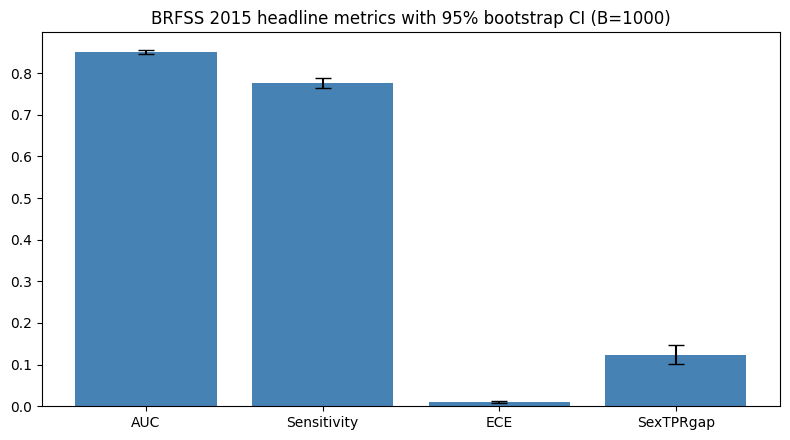

BOOTSTRAP CI SUMMARY
     metric   mean  ci_low  ci_high
        AUC 0.8503  0.8451   0.8552
      AUPRC 0.3702  0.3561   0.3839
      Brier 0.0706  0.0690   0.0720
        ECE 0.0112  0.0088   0.0135
Sensitivity 0.7762  0.7646   0.7878
  SexTPRgap 0.1240  0.1017   0.1476
--------------------------------------------------------------
Transport drift (sensitivity): 0.0249  95% CI [0.01, 0.0401]
READ: drift CI upper bound < 0.10 -> negligible-drift claim is statistically safe.


In [8]:
fig,ax=plt.subplots(figsize=(8,4.5))
order=['AUC','Sensitivity','ECE','SexTPRgap']
means=[[r['mean'] for r in ci_rows if r['metric']==k][0] for k in order]
los=[[r['ci_low'] for r in ci_rows if r['metric']==k][0] for k in order]
his=[[r['ci_high'] for r in ci_rows if r['metric']==k][0] for k in order]
yerr=[np.array(means)-np.array(los), np.array(his)-np.array(means)]
ax.bar(order, means, yerr=yerr, capsize=6, color='steelblue')
ax.set_title(f'BRFSS 2015 headline metrics with 95% bootstrap CI (B={B})')
plt.tight_layout(); plt.savefig(RES_CI+'/figures/fig_headline_ci.png',dpi=150,bbox_inches='tight'); plt.show()

print('='*62); print('BOOTSTRAP CI SUMMARY'); print('='*62)
print(ci_tab.to_string(index=False))
print('-'*62)
print(f"Transport drift (sensitivity): {dm}  95% CI [{dl}, {dh}]")
if dh < 0.10:
    print("READ: drift CI upper bound < 0.10 -> negligible-drift claim is statistically safe.")
else:
    print("READ: drift CI wider than expected; report the interval and temper wording.")
print('='*62)

### 9. Commit

In [9]:
%cd {REPO_DIR}
!git add results/brfss2015/bootstrap_ci results/brfss2020/shared_feature_transport
!git commit -m "Add bootstrap CIs on headline metrics and drift estimate (B=1000)"
!git push origin main

/content/drive/MyDrive/EXHEART_Research/exheart-research
[main def865f] Add bootstrap CIs on headline metrics and drift estimate (B=1000)
 4 files changed, 72 insertions(+), 1 deletion(-)
 create mode 100644 results/brfss2015/bootstrap_ci/figures/fig_headline_ci.png
 create mode 100644 results/brfss2015/bootstrap_ci/tables/headline_ci.csv
 create mode 100644 results/brfss2015/bootstrap_ci/tables/headline_ci.json
Enumerating objects: 21, done.
Counting objects: 100% (21/21), done.
Delta compression using up to 2 threads
Compressing objects: 100% (13/13), done.
Writing objects: 100% (14/14), 27.34 KiB | 965.00 KiB/s, done.
Total 14 (delta 5), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (5/5), completed with 5 local objects.
To https://github.com/anasbiswas1/exheart-research.git
   f25b22a..def865f  main -> main
